In [20]:
import pandas as pd
import matplotlib.pyplot as plt


In [21]:
df = pd.read_csv('data/raw/shopping.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Shipping Type,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,3475,NaN,Male,Jacket,30.904467,Maine,M,Burnt orange,Fall,4.0,Standard,No,0,Credit Card,NaN
1,3698,21.0,Female,Backpack,31.588259,NaN,L,Turquoise,Winter,2.0,Express,No,1,Credit Card,Monthly
2,2756,31.0,Male,Leggings,24.231704,Nevada,M,Terra cotta,Winter,4.0,Standard,No,0,Credit Card,NaN
3,3340,NaN,Male,Pajamas,33.918834,Nebraska,M,Black,Winter,NaN,Standard,No,2,Credit Card,Bi-Weekly
4,3391,38.0,Male,Sunglasses,36.545487,Oregon,S,Aubergine,Summer,NaN,Standard,No,0,Credit Card,NaN


In [22]:
#QUESTION 3:
season_summary = df.groupby("Season").agg(
    average_spending=("Purchase Amount (USD)", "mean"),
    total_revenue=("Purchase Amount (USD)", "sum"),
    purchase_frequency=("Customer ID", "count")
).reset_index()

season_summary


,Season,average_spending,total_revenue,purchase_frequency
0,Fall,38.830085,41004.570210,1056
1,Spring,39.293314,22829.415359,581
2,Summer,38.690885,36446.813666,942
3,Winter,38.366148,50681.682052,1321


In [24]:
#QUESTION 4:
ratings_summary = df.groupby("Review Rating").agg(
    average_previous_purchases=("Previous Purchases", "mean"),
    customer_count=("Customer ID", "count")
).reset_index()

ratings_summary


,Review Rating,average_previous_purchases,customer_count
0,1.0,4.693878,49
1,2.0,6.394495,218
2,3.0,0.000000,1
3,4.0,7.001399,715
4,5.0,6.765625,448


<Axes: xlabel='Location'>

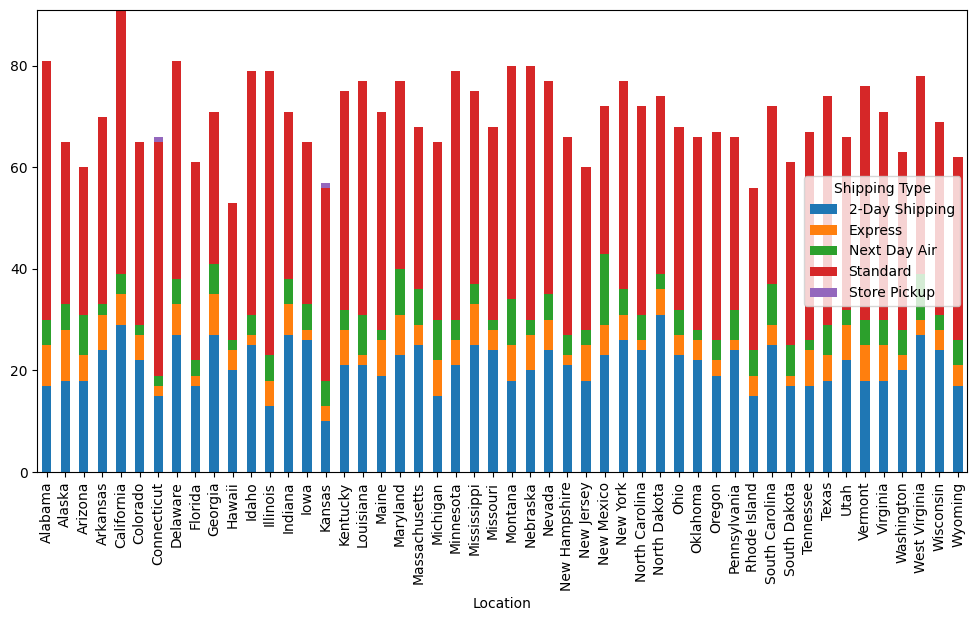

In [56]:
#   Question 5:
shipping_location_table = pd.pivot_table(
    df,
    index="Location",
    columns="Shipping Type",
    values="Customer ID",
    aggfunc="count",
    fill_value=0
)


shipping_location_table.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)


In [47]:
#Question 6:
item_spending = df.groupby("Item Purchased").agg(
    average_spending=("Purchase Amount (USD)", "mean"),
    total_sales=("Purchase Amount (USD)", "sum"),
    transaction_count=("Customer ID", "count")
).reset_index()


item_spending = item_spending.sort_values(
    by=["average_spending", "total_sales"] ,
    ascending=False
)

item_spending

,Item Purchased,average_spending,total_sales,transaction_count
8,Jeans,41.959073,2265.789949,54
5,Handbag,39.915359,10657.400907,267
0,Backpack,39.781731,8950.889542,225
10,Pajamas,39.729540,8422.662455,212
17,T-shirt,39.439705,10333.202786,262
9,Leggings,39.181546,8933.392444,228
1,Belt,39.144158,1330.901366,34
4,Gloves,39.066536,8477.438212,217
3,Dress,38.932151,11446.052462,294
13,Shorts,38.788655,12179.637629,314
